In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [ ]:
import pandas as pd

url = "https://drive.google.com/uc?id=1ki-coWNjVG0QGP60PoZtGkC0NhmtLcqW"
df = pd.read_csv(url)

print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2
)

In [ ]:
#Padding
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)

In [ ]:
#Build RNN Model
'''Embedding : Words → vectors
RNN : Learns sequence + context
Dense : Gives final prediction'''

from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(X_train_seq, maxlen=200)

In [ ]:
max_len = 200

X_test_seq = tokenizer.texts_to_sequences(X_test)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [ ]:
vocab_size = 10000 # from tokenizer (num_words)
maxlen = 200 # from pad_sequences (maxlen)

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100),
    SimpleRNN(units=32),
    Dense(units=1, activation='sigmoid')
])

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
earlystop = EarlyStopping(monitor='val_loss', patience=1)

In [ ]:
history = model.fit(X_train_pad, y_train, epochs=2, batch_size=128, validation_split=0.2)

Epoch 1/2
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 90ms/step - accuracy: 0.7791 - loss: 0.4736 - val_accuracy: 0.8169 - val_loss: 0.4334
Epoch 2/2
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.8774 - loss: 0.3044 - val_accuracy: 0.8639 - val_loss: 0.3452


In [ ]:
loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8644 - loss: 0.3384
Test Accuracy: 0.8644000291824341


In [ ]:
model.predict(X_test_pad[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


array([[0.9515564 ],
       [0.96845865],
       [0.9349975 ],
       [0.45420817],
       [0.882752  ]], dtype=float32)

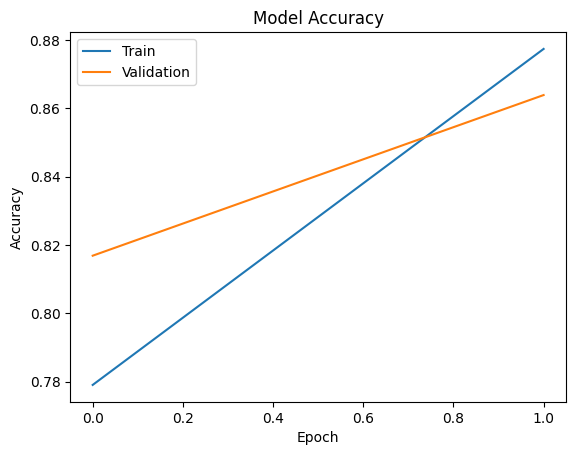

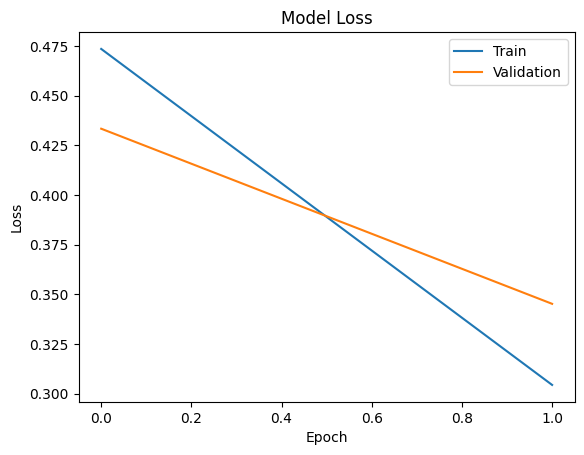

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()